5.1 Data Cleaning & Missing Value Strategy

1. Kiểm tra kích thước, cấu trúc & kiểu dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Load master dataset
df = pd.read_csv('../data/final/master_dataset.csv')

print("Số dòng, số cột:", df.shape)
print("\nThông tin dữ liệu")
print(df.info())

Số dòng, số cột: (10000, 39)

Thông tin dữ liệu
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      10000 non-null  str    
 1   Transaction_Date    10000 non-null  str    
 2   Customer_ID         10000 non-null  str    
 3   Gender              10000 non-null  str    
 4   Age                 10000 non-null  int64  
 5   City                10000 non-null  str    
 6   Product_ID          10000 non-null  int64  
 7   Product_Name        10000 non-null  str    
 8   Category            10000 non-null  str    
 9   Brand               10000 non-null  str    
 10  Quantity            10000 non-null  int64  
 11  Unit_Price_VND      10000 non-null  int64  
 12  Revenue             10000 non-null  int64  
 13  Source_Currency     10000 non-null  str    
 14  Rating              10000 non-null  int64  
 15  Customer_Review  

Đánh giá số lượng và tỷ lệ Missing Values của từng cột.

In [3]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percentage (%)': (df.isna().sum() / len(df)) * 100
}).query('Missing_Count > 0').sort_values(by='Missing_Count', ascending=False)

print("THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES)")
print(missing_summary)

THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES)
                  Missing_Count  Missing_Percentage (%)
avg_rating                 8178                   81.78
reviews_count              8178                   81.78
product_type               8178                   81.78
is_for_sale                8178                   81.78
availability               8178                   81.78
category_2                 8178                   81.78
category_3                 8178                   81.78
manufacturer               8178                   81.78
quantity_sold              1822                   18.22
review_count               1822                   18.22
rating_average             1822                   18.22
current_seller             1822                   18.22
fulfillment_type           1822                   18.22
date_created               1822                   18.22
number_of_images           1822                   18.22
favourite_count            1822                   18.22
has_vide

Trực quan hóa Missing Values bằng thư viện missingno.

<Figure size 1200x600 with 0 Axes>

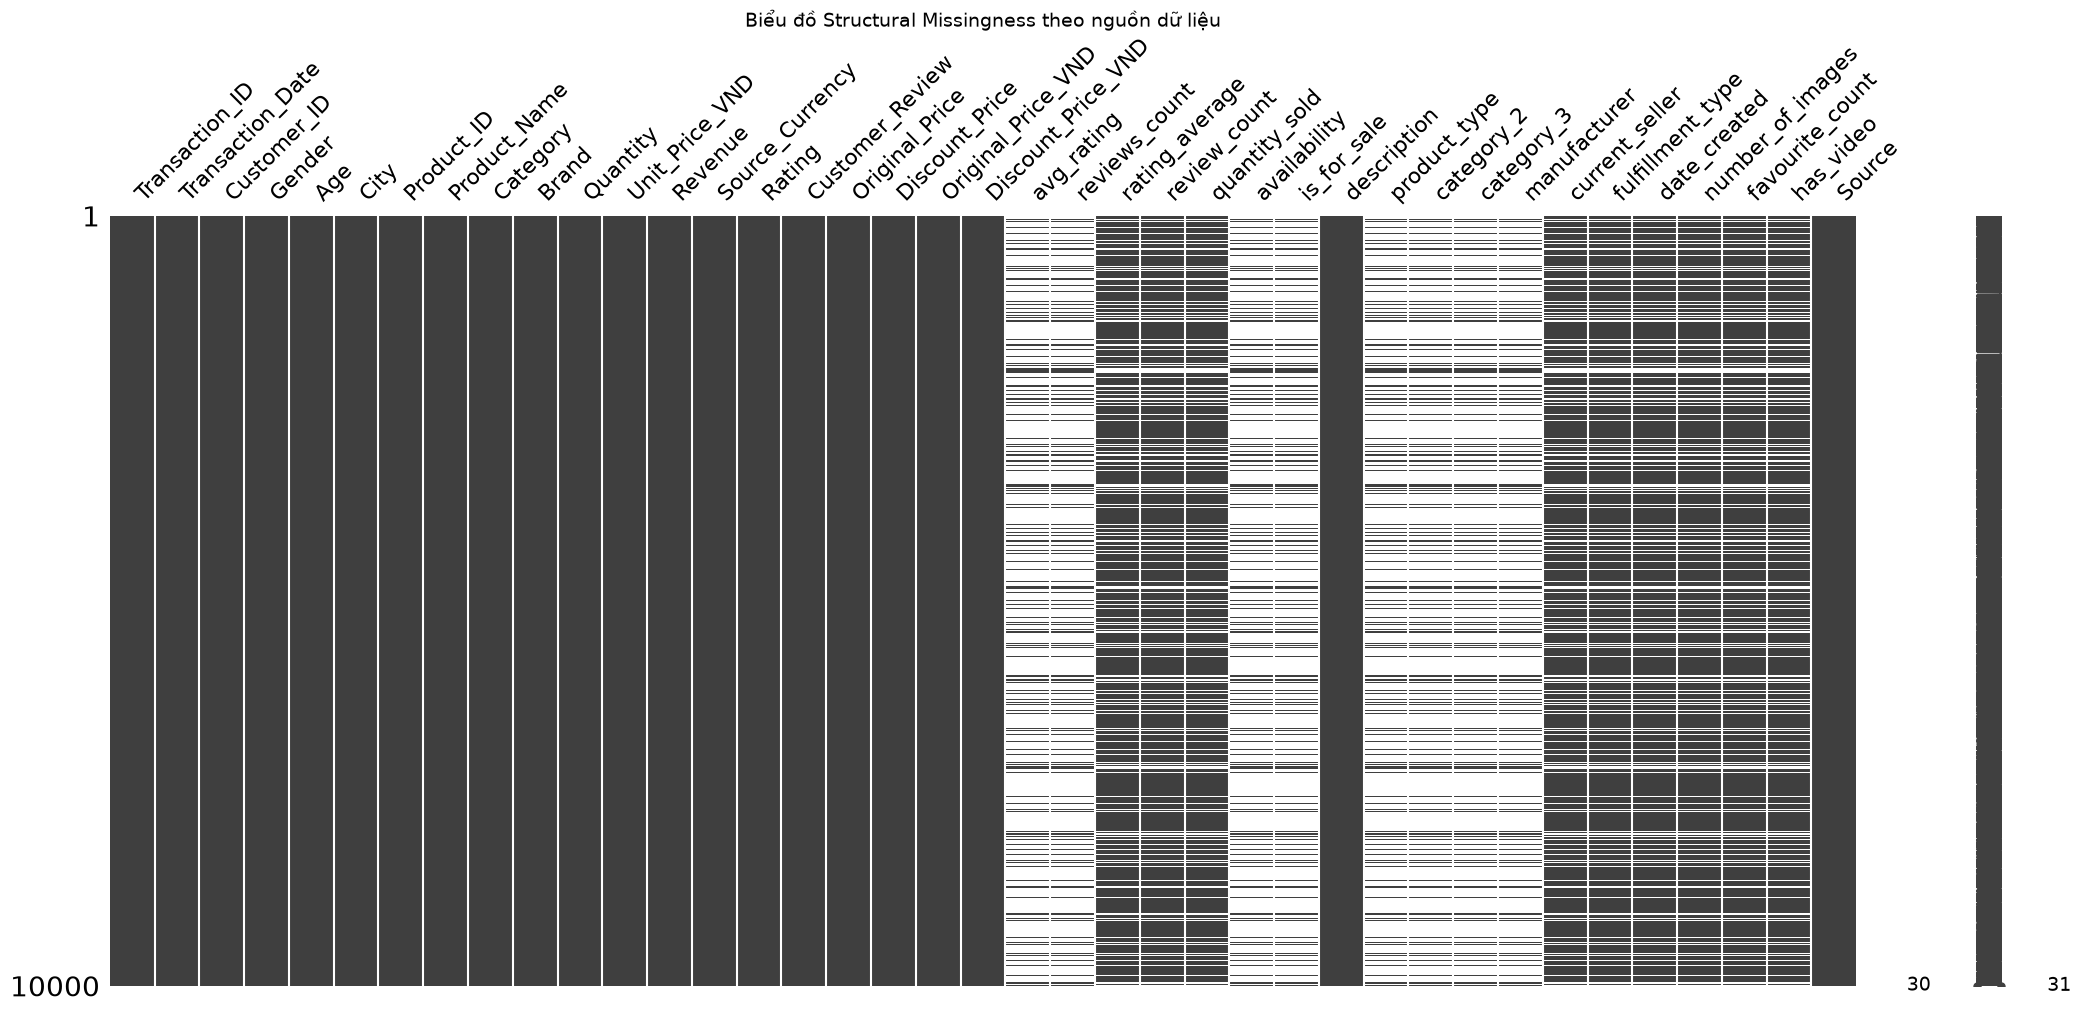

In [4]:
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title("Biểu đồ Structural Missingness theo nguồn dữ liệu", fontsize=14)
plt.show()

Phân tích cơ chế thiếu dữ liệu (MCAR / MAR / MNAR).

Dựa trên kết quả phân tích hệ thống, cơ chế khuyết dữ liệu của tập dữ liệu này thuộc dạng Missing by Design / Structural Missingness (Khuyết do cấu trúc tích hợp), xuất phát từ bản chất hợp nhất hai nguồn dữ liệu không đồng nhất:

Tập cột thiếu 8.178 dòng (81,78%): Gồm avg_rating, reviews_count, availability, is_for_sale, product_type, category_2, category_3, manufacturer.

Lý do: Các thuộc tính này thuộc về cấu trúc dữ liệu của Tesco UK. Do đó, toàn bộ 8.178 giao dịch xuất phát từ dữ liệu Tiki VN hoàn toàn không chứa các thuộc tính này.

Tập cột thiếu 1.822 dòng (18,22%): Gồm rating_average, review_count, quantity_sold, current_seller, fulfillment_type, date_created, number_of_images, favourite_count, has_video.

Lý do: Các thuộc tính này thuộc về cấu trúc Schema của sàn Tiki VN. Do đó, 1.822 giao dịch xuất phát từ Tesco UK bị khuyết hoàn toàn các trường thông tin này.

Quyết định xử lý: Không sử dụng phương pháp loại bỏ dòng dropna(), vì việc loại bỏ dữ liệu thiếu theo cấu trúc này sẽ dẫn đến việc xóa sạch toàn bộ 10.000 dòng dữ liệu (100% tập dữ liệu). Do đó, phương pháp điền thế thích hợp (Imputation theo từng nhóm đặc trưng nguồn) là bắt buộc.

Lựa chọn phương pháp xử lý Imputation phù hợp (Mean, Median, Mode, Unknown). Giải thích rõ lý do nếu dùng dropna().

In [5]:
# Sao chép dataframe trước khi điền
df_cleaned = df.copy()

# 1. Giữ nguyên dạng số cho rating_average, điền missing theo median của Category (nếu thiếu điền median chung)
if 'rating_average' in df.columns:
    df['rating_average'] = df.groupby('Category')['rating_average'].transform(lambda x: x.fillna(x.median()))
    df['rating_average'] = df['rating_average'].fillna(df['rating_average'].median())

# 2. Xử lý date_created: Chuyển sang datetime, giữ NaT hoặc điền bằng mốc thời gian giao dịch (Transaction_Date)
if 'date_created' in df.columns:
    df['date_created'] = pd.to_datetime(df['date_created'], errors='coerce')
    # Điền NaT bằng Transaction_Date nếu có
    if 'Transaction_Date' in df.columns:
        df['date_created'] = df['date_created'].fillna(pd.to_datetime(df['Transaction_Date'], errors='coerce'))

# 3. Các cột định lượng khác (review_count, quantity_sold, favourite_count, number_of_images)
num_cols_to_fill_zero = ['review_count', 'reviews_count', 'quantity_sold', 'favourite_count', 'number_of_images']
for col in num_cols_to_fill_zero:
    if col in df.columns:
        # Với số lượng đánh giá/bán, 0 có ý nghĩa logic là chưa có lượt tương tác
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 4. Các cột định tính (category_2, category_3, manufacturer, current_seller, fulfillment_type, product_type)
cat_cols_structural = ['category_2', 'category_3', 'manufacturer', 'current_seller', 'fulfillment_type', 'product_type', 'availability']
for col in cat_cols_structural:
    if col in df.columns:
        df[col] = df[col].fillna('Not Applicable')

# 5. Cột Boolean/Binary (is_for_sale, has_video)
bool_cols = ['is_for_sale', 'has_video']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].fillna(False)

print("Kiem tra missing values sau khi Imputation:")
print(df.isna().sum()[df.isna().sum() > 0])

Kiem tra missing values sau khi Imputation:
avg_rating    8178
dtype: int64


So sánh phân phối dữ liệu Before / After Imputation

In [6]:
import IPython.display as display
import pandas as pd

cat_missing_cols = [
    'availability',
    'is_for_sale',
    'product_type',
    'category_2',
    'category_3',
    'manufacturer',
    'current_seller',
    'fulfillment_type',
    'has_video',
    'avg_rating',
    'reviews_count',
]

num_missing_cols = [
    'rating_average',
    'review_count',
    'quantity_sold',
    'date_created',
    'number_of_images',
    'favourite_count',
]

#SO SÁNH CỘT ĐỊNH LƯỢNG 

print('=' * 90)
print('SO SÁNH CÁC CỘT ĐỊNH LƯỢNG')
print('=' * 90)

df_num_before = df[num_missing_cols].apply(pd.to_numeric, errors='coerce')
df_num_after = df_cleaned[num_missing_cols].apply(
    pd.to_numeric, errors='coerce'
)

print('\n---> TRƯỚC')
display.display(df_num_before.describe().round(2).T)

print('\n---> SAU')
display.display(df_num_after.describe().round(2).T)



#SO SÁNH CỘT ĐỊNH TÍNH

print('\n' + '=' * 90)
print('SO SÁNH CÁC CỘT ĐỊNH TÍNH')
print('=' * 90)

for col in cat_missing_cols:
    if col in df.columns:
        # Chuẩn hóa chuỗi và đánh dấu rõ ô Missing trước khi đếm
        s_before = df[col].fillna('<Missing / NaN>').astype(str)
        s_after = df_cleaned[col].astype(str)

        # Tạo 2 bảng tần suất độc lập
        df_before_stats = pd.DataFrame({
            'Count (Before)': s_before.value_counts(),
            '% (Before)': (s_before.value_counts(normalize=True) * 100).round(2),
        })

        df_after_stats = pd.DataFrame({
            'Count (After)': s_after.value_counts(),
            '% (After)': (s_after.value_counts(normalize=True) * 100).round(2),
        })

        # Ghép 2 bảng bằng pd.concat theo cột (axis=1) để tránh hoàn toàn lỗi Index
        df_vc_compare = pd.concat(
            [df_before_stats, df_after_stats], axis=1
        ).fillna(0)

        # Sắp xếp danh mục theo số lượng ở tập After giảm dần
        df_vc_compare = df_vc_compare.sort_values(
            by='Count (After)', ascending=False
        )

        print(f"\n--->Cột: '{col}'")
        display.display(df_vc_compare.head(10))

SO SÁNH CÁC CỘT ĐỊNH LƯỢNG

---> TRƯỚC


,count,mean,std,min,25%,50%,75%,max
rating_average,10000.0,1.220000e+00,2.020000e+00,0.0,0.0,0.0,3.4,5.000000e+00
review_count,10000.0,3.510000e+00,1.990000e+01,0.0,0.0,0.0,1.0,5.250000e+02
quantity_sold,10000.0,1.865000e+01,9.885000e+01,0.0,0.0,0.0,4.0,2.742000e+03
date_created,10000.0,3.233073e+17,6.850046e+17,0.0,388.0,650.0,1518.0,1.789873e+18
number_of_images,10000.0,5.020000e+00,4.000000e+00,0.0,1.0,5.0,8.0,4.100000e+01
favourite_count,10000.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00



---> SAU


,count,mean,std,min,25%,50%,75%,max
rating_average,8178.0,1.49,2.15,0.0,0.0,0.0,4.2,5.0
review_count,8178.0,4.29,21.93,0.0,0.0,0.0,1.0,525.0
quantity_sold,8178.0,22.81,108.88,0.0,0.0,1.0,6.0,2742.0
date_created,8178.0,1376.16,23058.99,0.0,321.0,550.0,839.0,738076.0
number_of_images,8178.0,6.13,3.56,1.0,3.0,6.0,9.0,41.0
favourite_count,8178.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0



SO SÁNH CÁC CỘT ĐỊNH TÍNH

--->Cột: 'availability'


...

,Count (Before),% (Before),Count (After),% (After)
has_video,,,,
False,9106,91.06,7284,89.07
True,894,8.94,894,10.93



--->Cột: 'avg_rating'


,Count (Before),% (Before),Count (After),% (After)
avg_rating,,,,
\N,1822,18.22,1822.0,100.0
<Missing / NaN>,8178,81.78,0.0,0.0



--->Cột: 'reviews_count'


,Count (Before),% (Before),Count (After),% (After)
reviews_count,,,,
\N,0.0,0.0,1822.0,100.0
0.0,10000.0,100.0,0.0,0.0


Đang vẽ biểu đồ cho 6 cột định lượng...


C:\Users\Ha Xuan Khoa\AppData\Local\Temp\ipykernel_23696\719774659.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


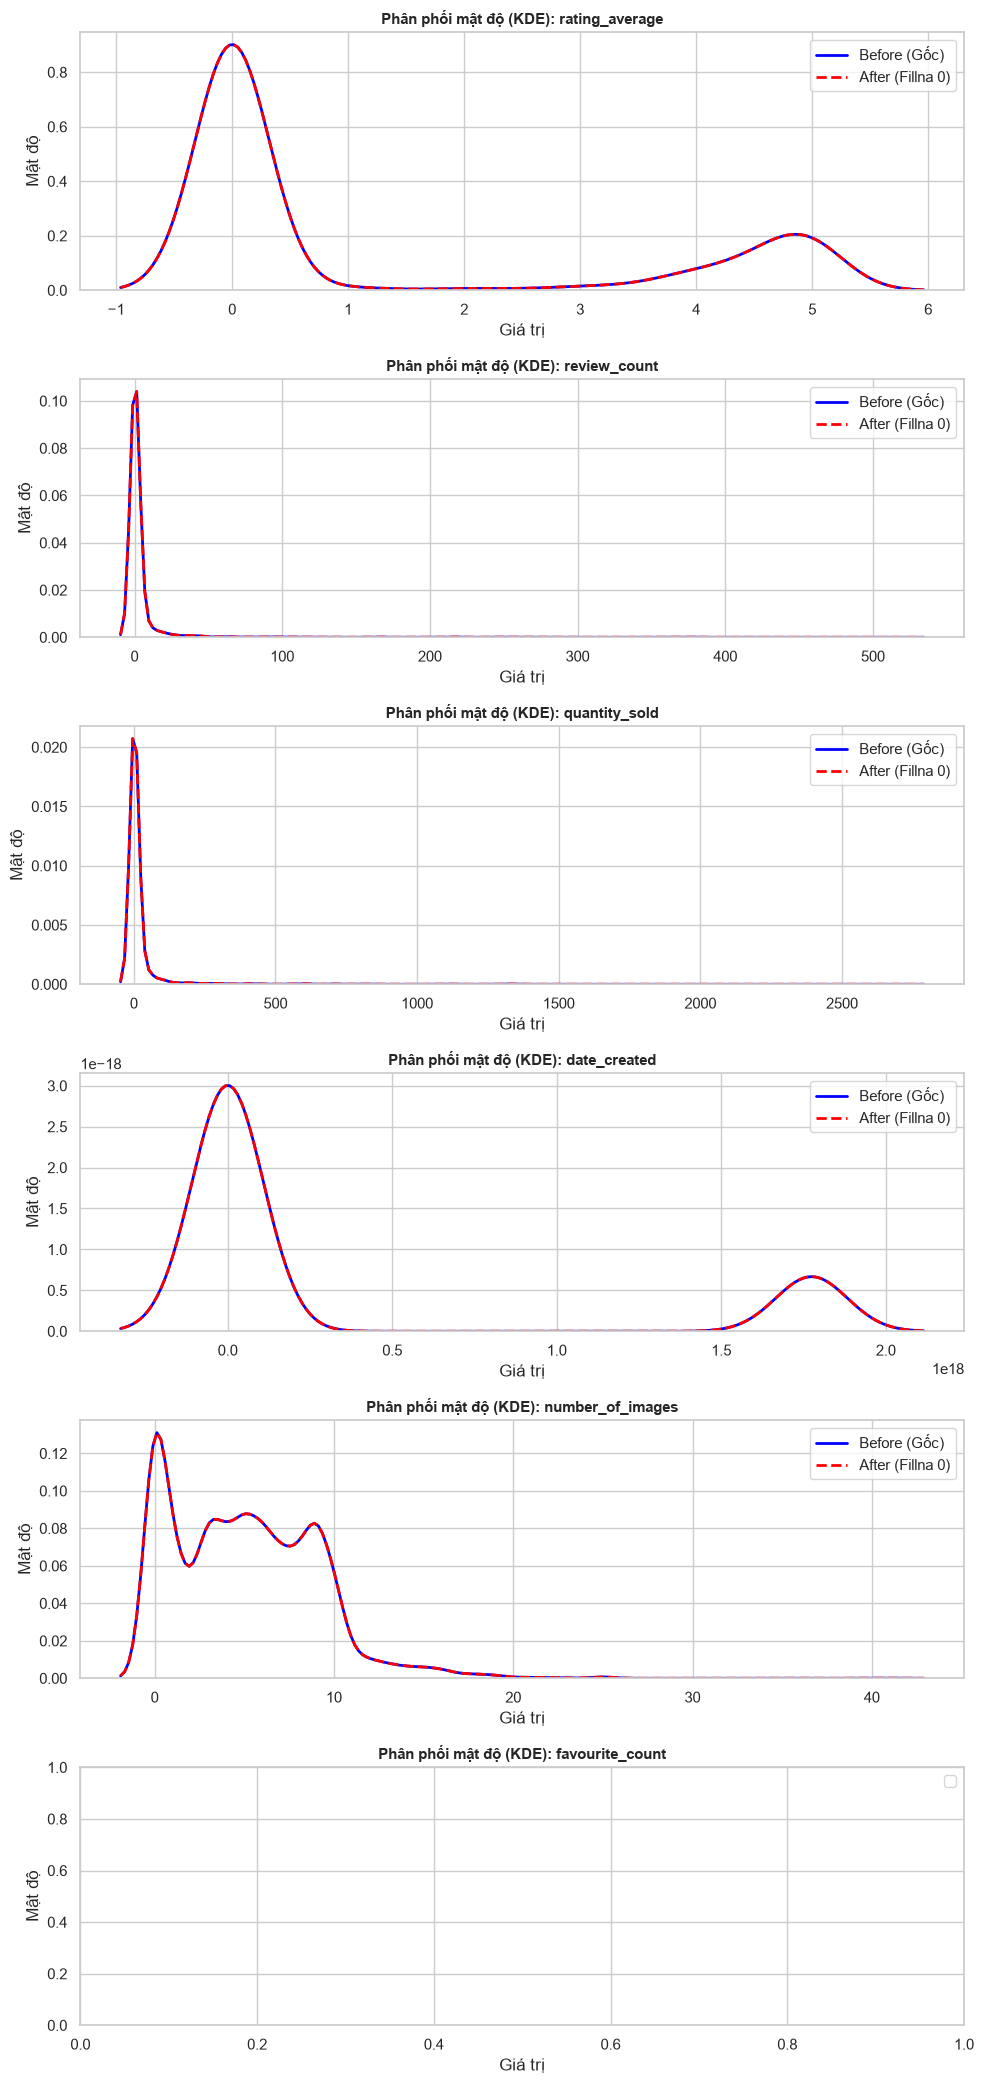

Đang vẽ biểu đồ cho 11 cột định tính...


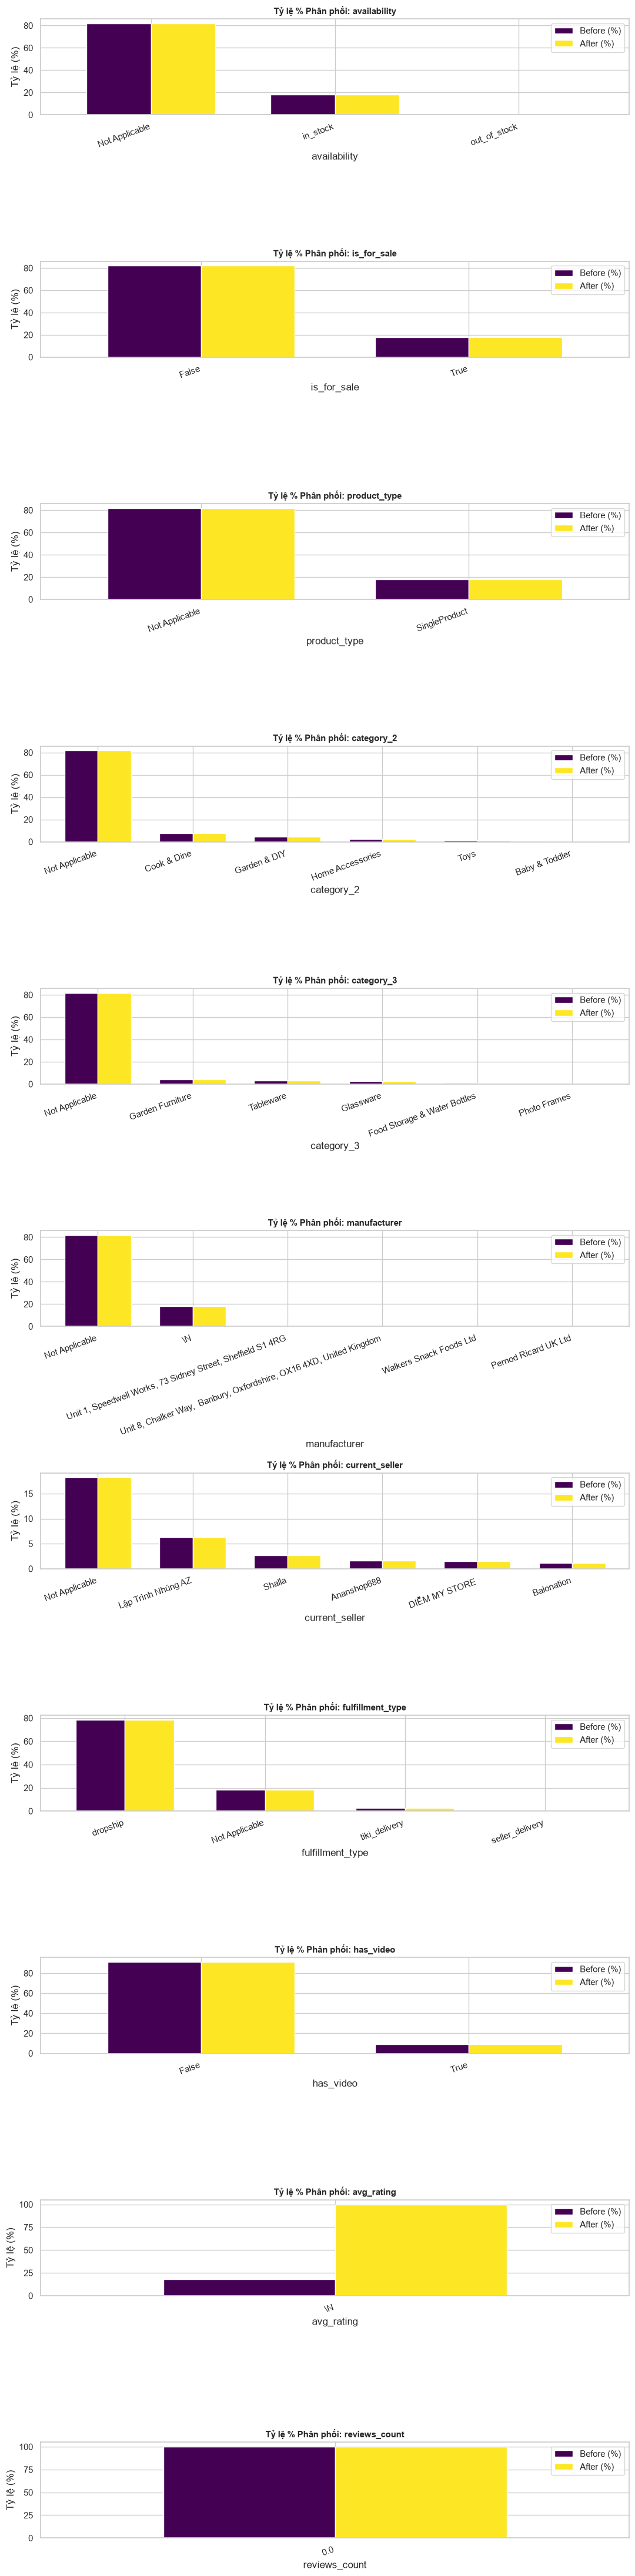

In [22]:
# ==============================================================================
# BIỂU ĐỒ SO SÁNH PHÂN PHỐI BEFORE / AFTER 
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

# ------------------------------------------------------------------------------
# 1. BIỂU ĐỒ CHO TẤT CẢ 6 CỘT ĐỊNH LƯỢNG (NUMERICAL)
# ------------------------------------------------------------------------------
print('Đang vẽ biểu đồ cho 6 cột định lượng...')
fig, axes = plt.subplots(
    len(num_missing_cols), 1, figsize=(10, 3.5 * len(num_missing_cols))
)

for i, col in enumerate(num_missing_cols):
    if col in df.columns:
        s_before = pd.to_numeric(df[col], errors='coerce').dropna()
        s_after = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0)

        sns.kdeplot(
            s_before,
            ax=axes[i],
            label='Before (Gốc)',
            color='blue',
            linewidth=2,
            warn_singular=False
        )
        sns.kdeplot(
            s_after,
            ax=axes[i],
            label='After (Fillna 0)',
            color='red',
            linestyle='--',
            linewidth=2,
            warn_singular=False
        )

        axes[i].set_title(
            f'Phân phối mật độ (KDE): {col}', fontsize=11, fontweight='bold'
        )
        axes[i].set_xlabel('Giá trị')
        axes[i].set_ylabel('Mật độ')
        axes[i].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 2. BIỂU ĐỒ CHO TẤT CẢ 11 CỘT ĐỊNH TÍNH (CATEGORICAL)
# ------------------------------------------------------------------------------
print('Đang vẽ biểu đồ cho 11 cột định tính...')
fig, axes = plt.subplots(
    len(cat_missing_cols), 1, figsize=(11, 4 * len(cat_missing_cols))
)

for i, col in enumerate(cat_missing_cols):
    if col in df.columns:
        # Lấy top 6 giá trị xuất hiện nhiều nhất ở tập After để vẽ
        top_cats = df_cleaned[col].astype(str).value_counts().head(6).index

        df_plot_before = (
            df[col]
            .fillna('<Missing>')
            .astype(str)
            .value_counts(normalize=True)
            .reindex(top_cats, fill_value=0)
            * 100
        )
        df_plot_after = (
            df_cleaned[col]
            .astype(str)
            .value_counts(normalize=True)
            .reindex(top_cats, fill_value=0)
            * 100
        )

        plot_data = pd.DataFrame(
            {'Before (%)': df_plot_before, 'After (%)': df_plot_after}
        )

        plot_data.plot(kind='bar', ax=axes[i], colormap='viridis', width=0.7)
        axes[i].set_title(
            f'Tỷ lệ % Phân phối: {col}', fontsize=11, fontweight='bold'
        )
        axes[i].set_ylabel('Tỷ lệ (%)')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=20, ha='right')
        axes[i].legend()

plt.tight_layout()
plt.show()

Phát hiện Outliers bằng IQR / Z-score và xử lý (Drop/Clip) tùy đặc điểm biến.

In [8]:

df_cleaned = df.copy()
# 1. Định nghĩa hàm tính toán chỉ số Outliers bằng IQR và Z-Score (Chỉ dùng để khảo sát)
def detect_outliers_summary(df, cols):
    outlier_info = []
    for col in cols:
        if not np.issubdtype(df[col].dtype, np.number):
            continue
        
        # IQR Method
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_iqr = Q1 - 1.5 * IQR
        upper_iqr = Q3 + 1.5 * IQR
        iqr_outliers = df[(df[col] < lower_iqr) | (df[col] > upper_iqr)].shape[0]
        
        # Z-Score Method (|Z| > 3)
        mean = df[col].mean()
        std = df[col].std()
        if std > 0:
            z_scores = (df[col] - mean) / std
            z_outliers = (np.abs(z_scores) > 3).sum()
        else:
            z_outliers = 0
            
        outlier_info.append({
            'Column': col,
            'IQR_Lower_Bound': lower_iqr,
            'IQR_Upper_Bound': upper_iqr,
            'IQR_Outliers_Count': iqr_outliers,
            'IQR_Outliers_Ratio (%)': round(iqr_outliers / len(df) * 100, 2),
            'ZScore_Outliers_Count': z_outliers,
            'ZScore_Outliers_Ratio (%)': round(z_outliers / len(df) * 100, 2)
        })
    return pd.DataFrame(outlier_info)

# Các cột số chính cần phân tích
numeric_cols = [
    'Age', 'Quantity', 'Unit_Price_VND', 'Revenue', 
    'Original_Price_VND', 'Discount_Price_VND', 
    'rating_average', 'review_count', 'quantity_sold'
]

print("=== THỐNG KÊ OUTLIERS BẰNG IQR & Z-SCORE ===")
outlier_df = detect_outliers_summary(df, [c for c in numeric_cols if c in df.columns])
print(outlier_df.to_string(index=False))

# ------------------------------------------------------------------------------
# 2. XỬ LÝ OUTLIER DỰA TRÊN BẢN CHẤT LOGIC CỦA TỪNG BIẾN (DOMAIN KNOWLEDGE)
# ------------------------------------------------------------------------------

initial_shape = df.shape
print(f"\nKích thước dữ liệu ban đầu: {initial_shape}")

# --- TRƯỜNG HỢP 1: Xóa/Sửa các giá trị VI PHẠM LOGIC (Sai dữ liệu thực tế) ---

# a. Độ tuổi (Age): Tuổi phải nằm trong khoảng hợp lý (ví dụ: 10 đến 100 tuổi)
if 'Age' in df.columns:
    invalid_age = df[(df['Age'] < 10) | (df['Age'] > 100)]
    print(f"Số dòng vi phạm logic Tuổi (<10 hoặc >100): {len(invalid_age)}")
    df = df[(df['Age'] >= 10) & (df['Age'] <= 100)]

# b. Giá bán & Doanh thu (Unit_Price_VND, Revenue, Quantity): Không thể âm hoặc bằng 0 trong giao dịch hợp lệ
invalid_financials = df[
    (df['Quantity'] <= 0) | 
    (df['Unit_Price_VND'] < 0) | 
    (df['Revenue'] < 0)
]
print(f"Số dòng vi phạm logic Giá/Số lượng/Doanh thu (<= 0): {len(invalid_financials)}")
df = df[
    (df['Quantity'] > 0) & 
    (df['Unit_Price_VND'] >= 0) & 
    (df['Revenue'] >= 0)
]

# c. Đánh giá (Rating / rating_average): Phải nằm trong thang điểm 1 - 5 (hoặc 0 - 5)
if 'rating_average' in df.columns:
    invalid_rating = df[(df['rating_average'] < 0) | (df['rating_average'] > 5)]
    print(f"Số dòng vi phạm logic Rating (<0 hoặc >5): {len(invalid_rating)}")
    df = df[df['rating_average'].isna() | ((df['rating_average'] >= 0) & (df['rating_average'] <= 5))]


# --- TRƯỜNG HỢP 2: Giữ lại Outliers HỢP LỆ (Lượng mua lớn, Giá trị cao thực tế) ---
# Đối với các biến như Quantity, Revenue, Discount_Price_VND, quantity_sold:
# Các giá trị nằm ngoài vạch IQR/Z-score nhưng KHÔNG vi phạm logic ở trên sẽ ĐƯỢC GIỮ NGUYÊN 
# vì đây thể hiện hành vi mua sắm thực tế (khách hàng VIP, mua sỉ, khuyến mãi khủng).


# --- TRƯỜNG HỢP 3: Giới hạn (Clip/Winsorize) có kiểm soát đối với các biến phân phối lệch cực đoan (Nếu cần thiết cho mô hình ML) ---
# Ví dụ: Chỉ Capping/Clipping ở percentile 99.9% thay vì 1.5*IQR để tránh làm biến dạng dữ liệu quá nhiều.

cols_to_cap = ['Revenue', 'Quantity']
for col in cols_to_cap:
    if col in df.columns:
        upper_limit = df[col].quantile(0.999) # Giữ lại 99.9% dữ liệu gốc
        outliers_capped = (df[col] > upper_limit).sum()
        df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
        print(f"Đã Clip cột '{col}' tại ngưỡng 99.9% ({upper_limit}): {outliers_capped} giá trị được điều chỉnh.")

# Summary kết quả sau xử lý
print(f"\nKích thước dữ liệu sau khi làm sạch Outlier: {df.shape}")
print(f"Số dòng đã bị xoá (loại bỏ lỗi logic): {initial_shape[0] - df.shape[0]} dòng ({(initial_shape[0] - df.shape[0])/initial_shape[0]*100:.2f}%)")

=== THỐNG KÊ OUTLIERS BẰNG IQR & Z-SCORE ===
            Column  IQR_Lower_Bound  IQR_Upper_Bound  IQR_Outliers_Count  IQR_Outliers_Ratio (%)  ZScore_Outliers_Count  ZScore_Outliers_Ratio (%)
               Age            -7.00            89.00                   0                    0.00                      0                       0.00
          Quantity            -1.00             7.00                   0                    0.00                      0                       0.00
    Unit_Price_VND       -793500.00       1482500.00                1088                   10.88                    191                       1.91
           Revenue      -2435001.25       4485000.75                1053                   10.53                    159                       1.59
Original_Price_VND       -879718.00       1639530.00                1072                   10.72                    185                       1.85
Discount_Price_VND       -793500.00       1482500.00                1088 

# 5.2. Exploratory Data Analysis (EDA) 

In [9]:
# Phân tích Univariate (Thống kê mô tả, phân phối).
# Đảm bảo chúng ta có tập dữ liệu df_cleaned đã được xử lý đầy đủ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Thiết lập giao diện biểu đồ
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Danh sách các biến định lượng (bao gồm cả các biến mới từ Feature Engineering)
key_numeric_cols = [
    'Age', 'Quantity', 'Unit_Price_VND', 'Revenue', 
    'Rating', 'Discount_Ratio', 'product_static_rating'
]
valid_cols = [c for c in key_numeric_cols if c in df_cleaned.columns]

# 3. Thống kê mô tả dạng bảng
print("THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CHÍNH XUYÊN SUỐT:")
try:
    display(df_cleaned[valid_cols].describe().round(2))
except NameError:
    print(df_cleaned[valid_cols].describe().round(2))

THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CHÍNH XUYÊN SUỐT:


,Age,Quantity,Unit_Price_VND,Revenue,Rating
count,10000.00,10000.00,10000.00,1.000000e+04,10000.00
mean,41.38,3.01,726136.40,2.199967e+06,3.01
std,13.80,1.41,1743641.39,5.979453e+06,1.42
min,18.00,1.00,1000.00,1.000000e+03,1.00
25%,29.00,2.00,60000.00,1.599995e+05,2.00
50%,41.00,3.00,275507.50,6.125000e+05,3.00
75%,53.00,4.00,629000.00,1.890000e+06,4.00
max,65.00,5.00,32324592.00,1.213735e+08,5.00


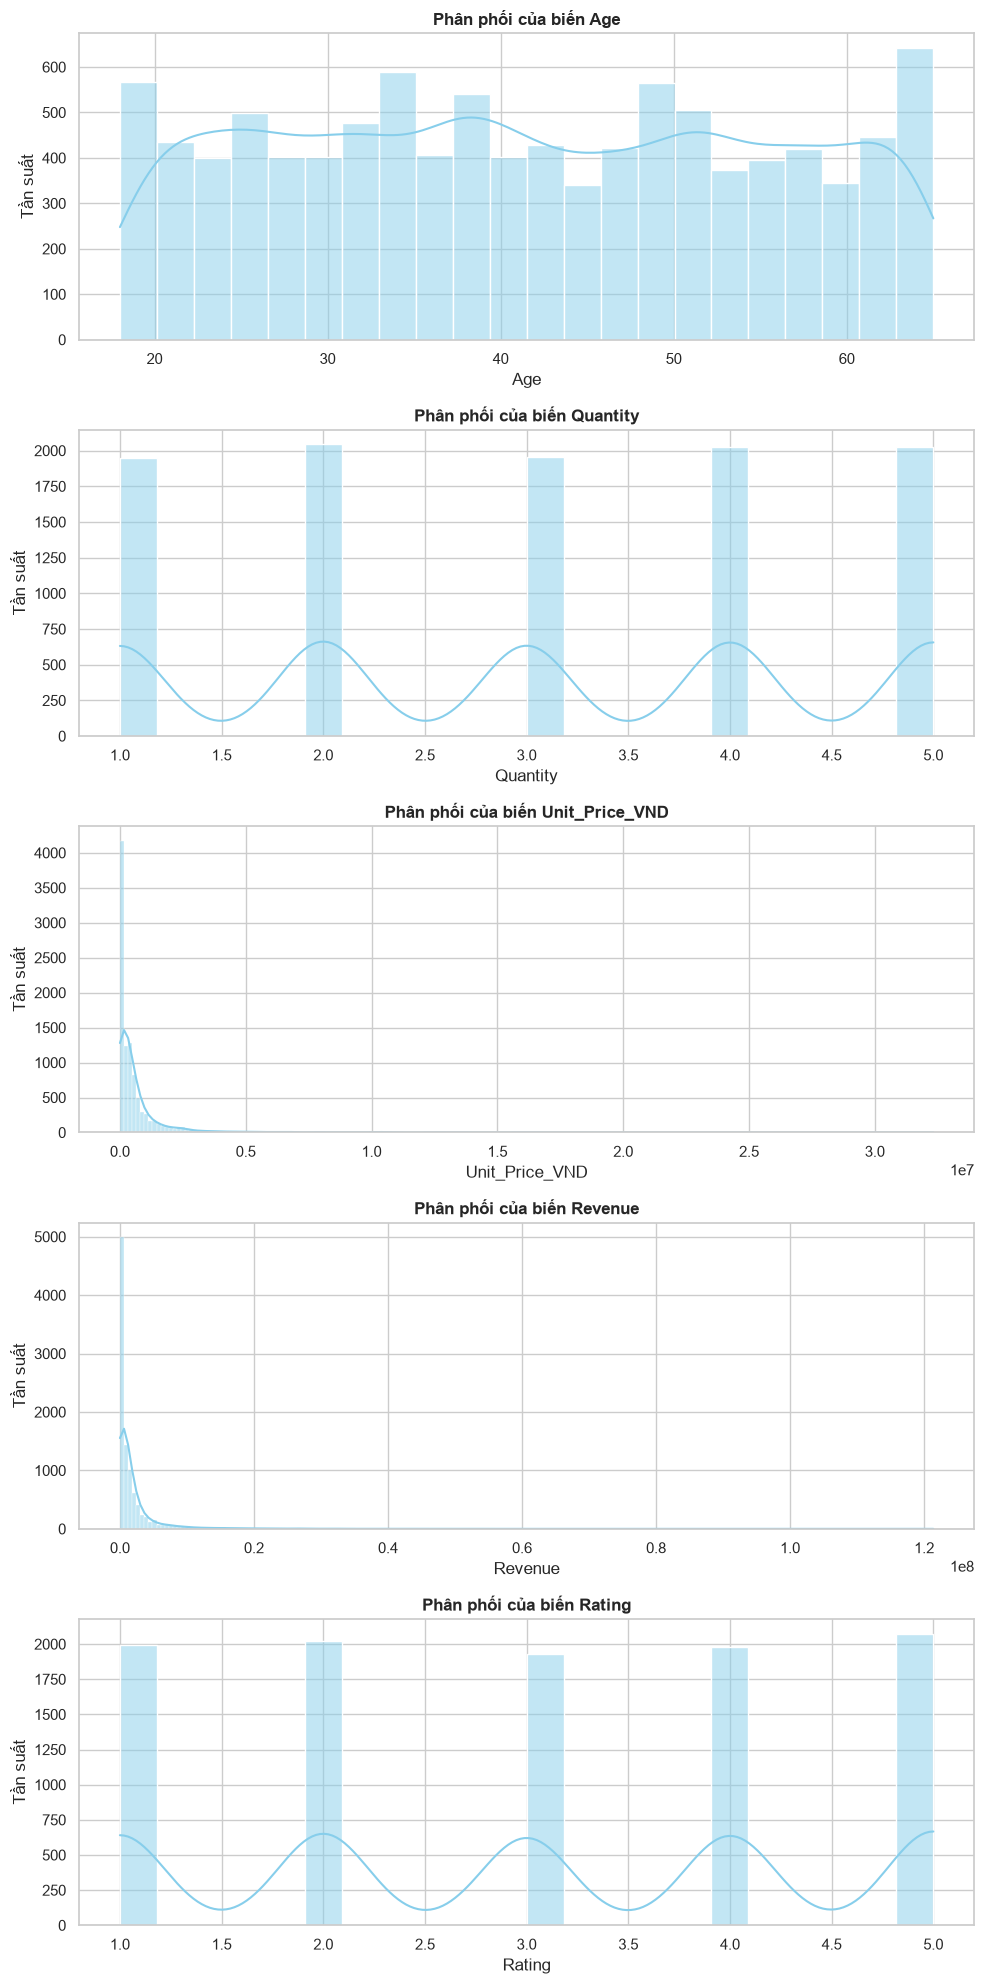

In [10]:
#trực quan hóa phân phối cho từng biến.
fig, axes = plt.subplots(nrows=len(valid_cols), ncols=1, figsize=(10, 4 * len(valid_cols)))
if len(valid_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, valid_cols):
    sns.histplot(data=df_cleaned, x=col, kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Phân phối của biến {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

# 1. Tính toán Discount_Ratio dựa trên giá VND
# Sử dụng np.where để xử lý an toàn trường hợp Original_Price_VND = 0 (tránh lỗi chia cho 0)
df['Discount_Ratio'] = np.where(
    df['Original_Price_VND'] > 0,
    (df['Original_Price_VND'] - df['Discount_Price_VND']) / df['Original_Price_VND'],
    0
)

# 2. Phân loại và chuẩn hóa Rating
# Ép kiểu avg_rating (hiện là object) sang dạng số
df['avg_rating_num'] = pd.to_numeric(df['avg_rating'], errors='coerce')

# Gom chung 2 cột static rating lại thành 1 feature đại diện cho danh tiếng chung của sản phẩm
df['product_static_rating'] = df['rating_average'].fillna(df['avg_rating_num'])


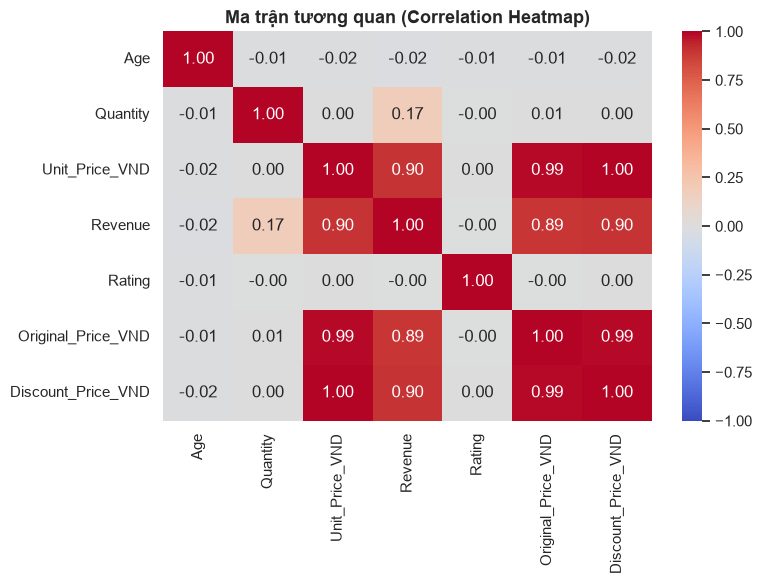

In [12]:
##Phân tích Bivariate/Multivariate và ma trận tương quan (Correlation Heatmap).
plt.figure(figsize=[8,6])
num_cols = ['Age','Quantity','Unit_Price_VND','Revenue','Rating','Original_Price_VND', 'Discount_Price_VND']
corr = df_cleaned[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan (Correlation Heatmap)', fontsize =13, fontweight='bold')
plt.tight_layout()
plt.show()

# Vẽ các biểu đồ bằng Matplotlib / Seaborn (đầy đủ Title, X/Y labels).

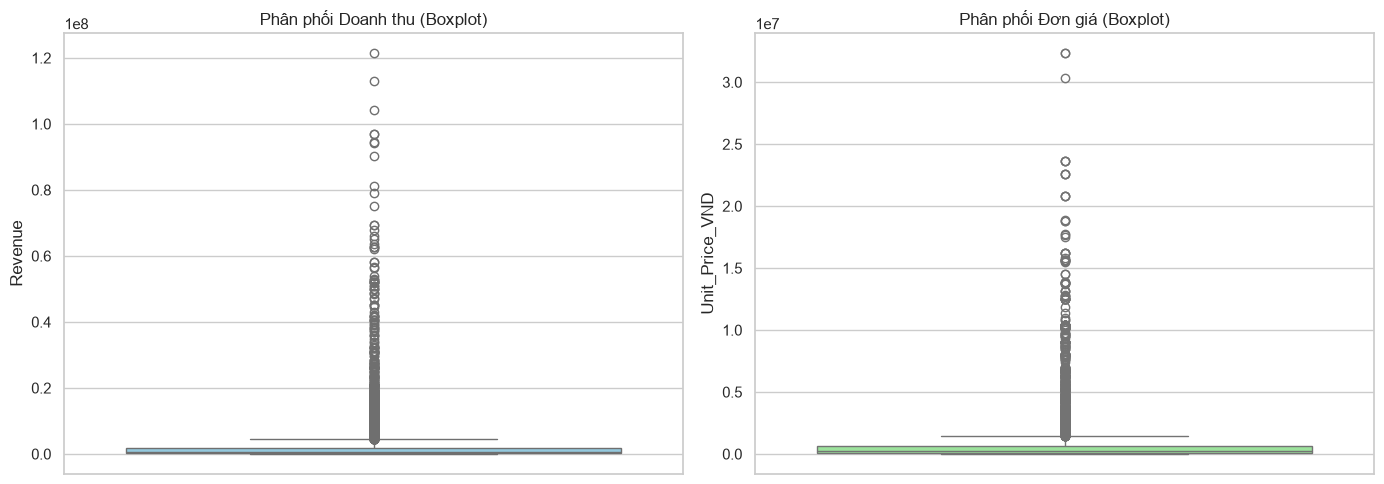

In [13]:
#Biểu đồ 0: Trực quan hóa phân phối giữa Doanh Thu và Đơn Giá.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df_cleaned['Revenue'], ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Doanh thu (Boxplot)')

sns.boxplot(y=df_cleaned['Unit_Price_VND'], ax=axes[1], color='lightgreen')
axes[1].set_title('Phân phối Đơn giá (Boxplot)')
plt.tight_layout()
plt.show()

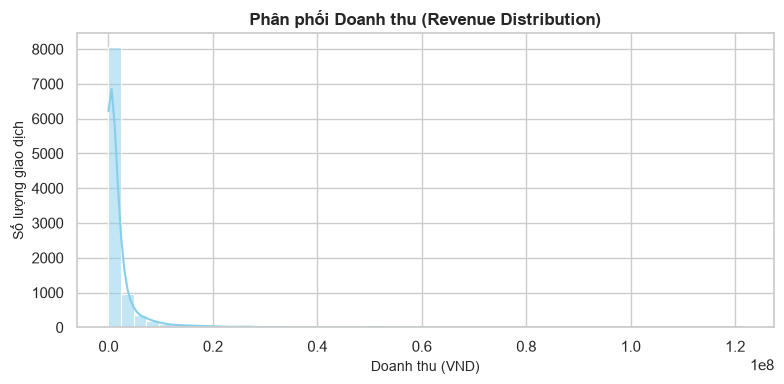

In [14]:
# Biểu đồ 1: Revenue Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['Revenue'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối Doanh thu (Revenue Distribution)', fontsize=12, fontweight='bold')
plt.xlabel('Doanh thu (VND)', fontsize=10)
plt.ylabel('Số lượng giao dịch', fontsize=10)
plt.tight_layout()
plt.show()

# Insight: 
Phân phối Doanh thu có dạng lệch phải (Right-skewed) cực lớn.
Dựa vào biểu đồ này, Giá trị đơn hàng ghi nhận sự phân hóa rõ rệt. Tổng doanh thu có xu hướng phụ thuộc vào một tỷ lệ nhỏ các giao dịch có giá trị cực cao (nguyên lý 80/20), trong khi đại đa số đơn hàng đóng góp ở mức giá trị trung bình thấp.

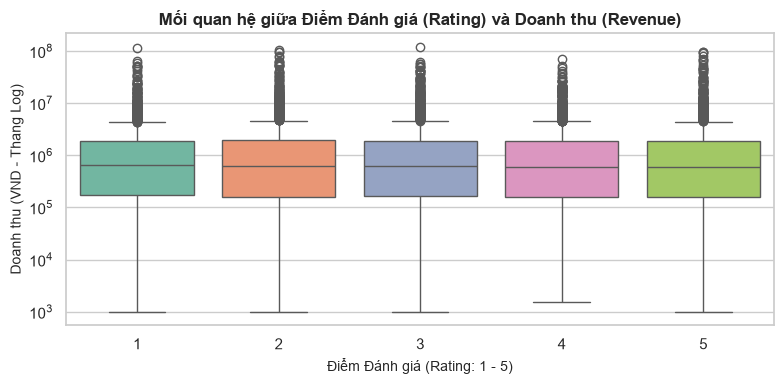

In [15]:
#Biểu đồ 2: Thang đo Logarithm
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_cleaned, x='Rating', y='Revenue', palette='Set2', hue='Rating', legend=False)
plt.yscale('log')
plt.title('Mối quan hệ giữa Điểm Đánh giá (Rating) và Doanh thu (Revenue)', fontsize=12, fontweight='bold')
plt.xlabel('Điểm Đánh giá (Rating: 1 - 5)', fontsize=10)
plt.ylabel('Doanh thu (VND - Thang Log)', fontsize=10)
plt.tight_layout()
plt.show()

# Insight:
* Trung vị tương đồng: Doanh thu giữa các mức Rating (1–5 sao) không cho thấy sự khác biệt rõ rệt. Giá trị đơn hàng lớn hay nhỏ chưa ghi nhận sự liên hệ với điểm đánh giá.

* Rủi ro ở đơn hàng lớn: Các giao dịch doanh thu cao (outliers) xuất hiện ở cả nhóm 1–2 sao lẫn 4–5 sao, phản ánh rủi ro trải nghiệm tiêu cực vẫn có xu hướng xảy ra trên cả các đơn hàng giá trị cao.
# Phân biệt Correlation và Causation: 
* Hệ số tương quan ($\approx 0$): Dữ liệu ghi nhận hệ số tương quan giữa Rating và Revenue xấp xỉ bằng $0$.  
* Không tồn tại quan hệ nhân quả: Rating cao không "gây ra" (Causation) việc khách hàng chi trả nhiều tiền hơn cho một đơn hàng.   
* Bản chất của hai biến: Giá trị đơn hàng (Revenue) cao hay thấp phụ thuộc hoàn toàn vào đặc thù định giá của chính sản phẩm đó. Trong khi đó, Rating chỉ phản ánh mức độ hài lòng của người mua sau khi đã nhận được hàng

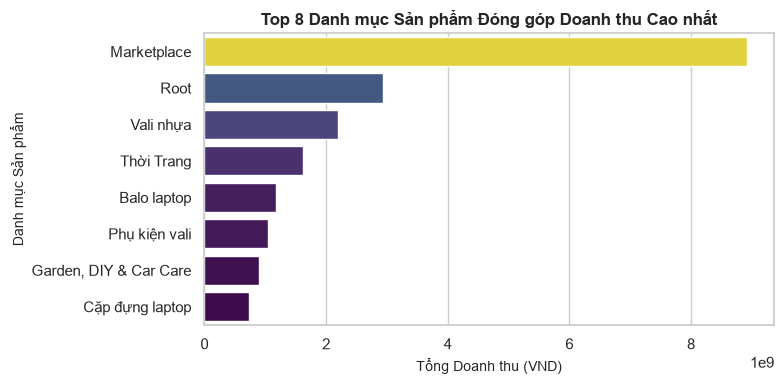

In [16]:
#Biểu đồ 3: Top 8 Danh mục có Tổng Doanh thu Cao nhất
top_cats = df_cleaned.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(8).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=top_cats, x='Revenue', y='Category', palette='viridis', hue='Revenue', legend=False)
plt.title('Top 8 Danh mục Sản phẩm Đóng góp Doanh thu Cao nhất', fontsize=12, fontweight='bold')
plt.xlabel('Tổng Doanh thu (VND)', fontsize=10)
plt.ylabel('Danh mục Sản phẩm', fontsize=10)
plt.tight_layout()
plt.show()

# Insight:
* Tập trung doanh thu: Tổng doanh thu có xu hướng phụ thuộc lớn vào các danh mục ở nhóm đầu, cho thấy vai trò trụ cột của một số ít nhóm ngành hàng trong việc đóng góp vào quy mô dòng tiền chung.

* Sự phân hóa quy mô: Có khoảng cách rõ rệt về giá trị đóng góp giữa các danh mục dẫn đầu so với các danh mục ở nhóm dưới của Top 8.

* Cơ cấu đóng góp: Tổng doanh thu cao ở các danh mục này thường đi kèm với sản lượng tiêu thụ lớn, đơn giá sản phẩm thuộc phân khúc trung-cao, hoặc sự kết hợp của cả hai yếu tố.

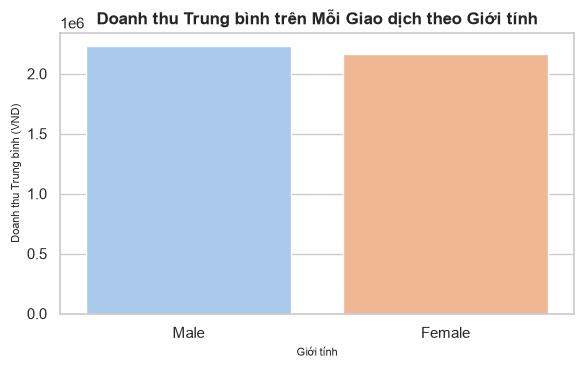

In [17]:
#Biểu đồ 4: So sánh Doanh thu Trung bình theo Giới tính
plt.figure(figsize=(6, 4))
sns.barplot(data=df_cleaned, x='Gender', y='Revenue', estimator=np.mean, errorbar=None, palette='pastel', hue='Gender', legend=False)
plt.title('Doanh thu Trung bình trên Mỗi Giao dịch theo Giới tính', fontsize=12, fontweight='bold')
plt.xlabel('Giới tính', fontsize=8)
plt.ylabel('Doanh thu Trung bình (VND)', fontsize=8)
plt.tight_layout()
plt.show()

# Insight:
* Sự đồng đều về sức chi: Mức chi tiêu trung bình trên mỗi đơn hàng giữa các nhóm giới tính có xu hướng tương đồng, không ghi nhận sự chênh lệch đáng kể.

* Mối liên hệ với giá trị đơn: Yếu tố giới tính chưa cho thấy sự liên hệ rõ rệt với giá trị của một giao dịch đơn lẻ.

* Định hướng phân tích quy mô: Sự khác biệt về tổng doanh thu giữa các nhóm khách hàng (nếu có) thường đi kèm với tần suất mua hàng và quy mô tập khách hàng, thay vì giá trị trung bình trên từng đơn hàng.

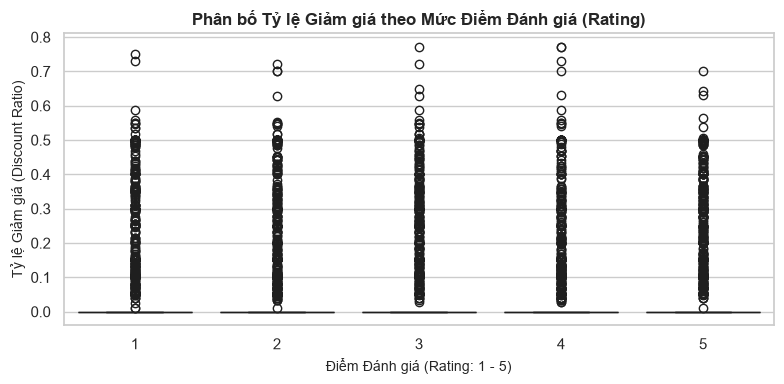

In [18]:
#Biểu đồ 5: Biểu đồ tỷ lệ giảm giá:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_cleaned['Discount_Ratio'] = np.where(
    df_cleaned['Original_Price_VND'] > 0,
    (df_cleaned['Original_Price_VND'] - df_cleaned['Discount_Price_VND']) / df_cleaned['Original_Price_VND'],
    0
)

# Vẽ biểu đồ Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_cleaned, x='Rating', y='Discount_Ratio', palette='Blues_d', hue='Rating', legend=False)
plt.title('Phân bố Tỷ lệ Giảm giá theo Mức Điểm Đánh giá (Rating)', fontsize=12, fontweight='bold')
plt.xlabel('Điểm Đánh giá (Rating: 1 - 5)', fontsize=10)
plt.ylabel('Tỷ lệ Giảm giá (Discount Ratio)', fontsize=10)
plt.tight_layout()
plt.show()

# Insight:
* Sự tương đồng về vị trí trung vị: Mức tỷ lệ giảm giá trung vị (Discount_Ratio) giữa các nhóm Rating từ 1 đến 5 sao có xu hướng tương đồng nhau, không ghi nhận sự chênh lệch đáng kể.

* Mối liên hệ giữa Giảm giá và Trải nghiệm: Tỷ lệ giảm giá cao hay thấp chưa ghi nhận sự liên hệ trực tiếp với điểm đánh giá giao dịch (Rating). Khuyến mãi sâu không có xu hướng tự động làm tăng hay giảm sự hài lòng của khách hàng.

* Mức độ phủ của chương trình khuyến mãi: Các đơn hàng có tỷ lệ giảm giá lớn (ngoại biệt) xuất hiện rải rác ở cả 5 mức Rating, phản ánh các chính sách giảm giá được áp dụng chung trên dải sản phẩm rộng chứ không tập trung vào một nhóm trải nghiệm riêng biệt.

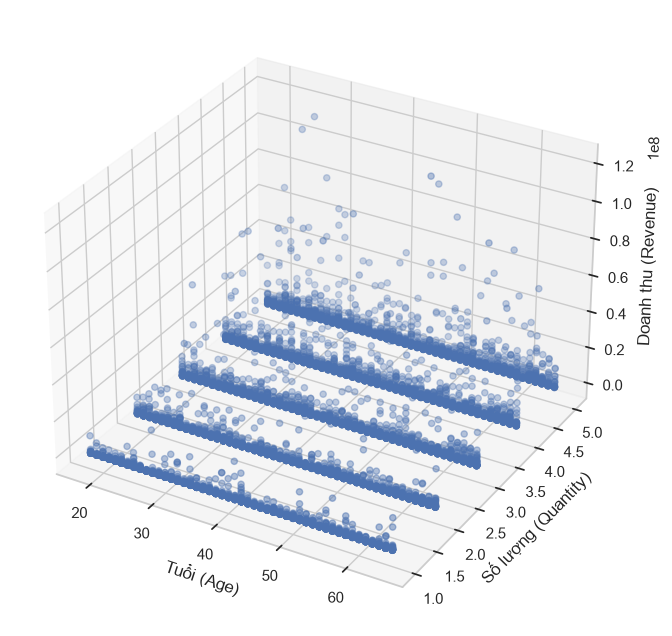

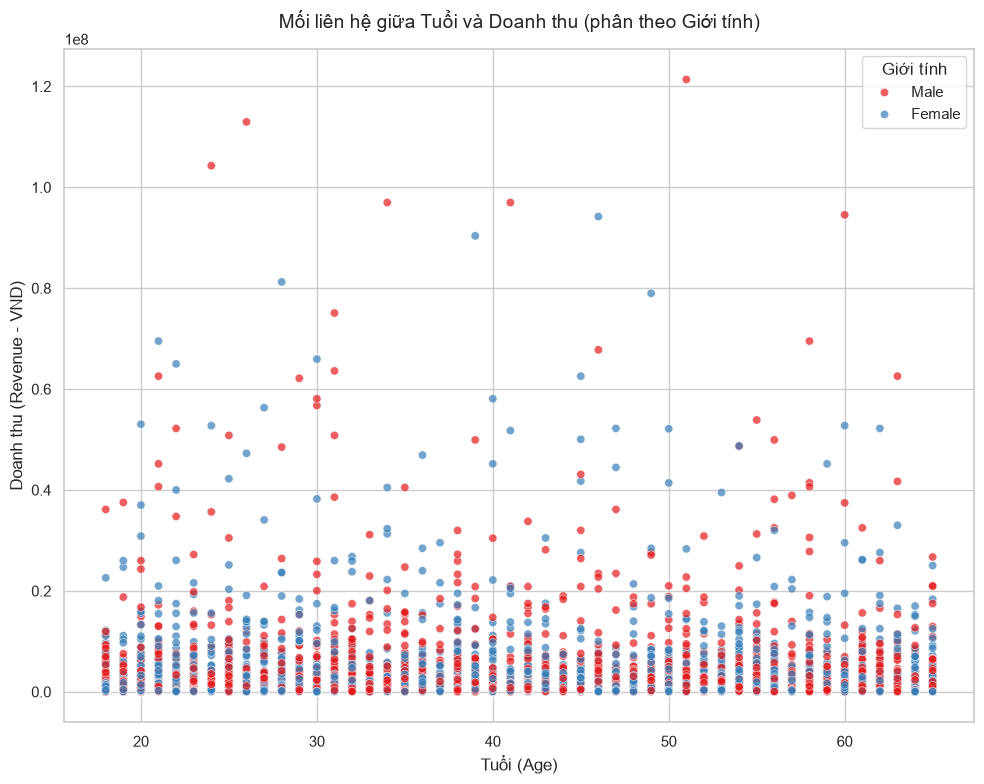

In [19]:
#Biểu đồ đặc biệt: Sự thay đổi giữa giới tính và doanh thu (Scatter Plot).
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d") 
ax.scatter(
    xs=df_cleaned['Age'], 
    ys=df_cleaned['Quantity'], 
    zs=df_cleaned['Revenue'],  
    alpha=0.7
)

ax.set_xlabel('Tuổi (Age)')
ax.set_ylabel('Số lượng (Quantity)')
ax.set_zlabel('Doanh thu (Revenue)')
plt.show()

#Biểu đồ khác: 
fig, ax = plt.subplots(figsize=(10, 8))
sns.set_theme(style='whitegrid')
sns.scatterplot(
    data=df_cleaned,
    x='Age',
    y='Revenue',
    hue='Gender', 
    alpha=0.7,    
    palette='Set1',
    ax=ax
)

plt.title('Mối liên hệ giữa Tuổi và Doanh thu (phân theo Giới tính)', fontsize=14, pad=15)
plt.xlabel('Tuổi (Age)', fontsize=12)
plt.ylabel('Doanh thu (Revenue - VND)', fontsize=12)
plt.legend(title='Giới tính')
plt.tight_layout()
plt.show()

# Insight: 
* Biểu đồ 3D Scatter (Age – Quantity – Revenue)
- * Yếu tố tác động đến Doanh thu: Các mức doanh thu cao (Revenue) có xu hướng tập trung mạnh ở các điểm có số lượng mua lớn (Quantity), trong khi độ tuổi (Age) phân bổ tương đối đồng đều trên toàn bộ trục.

- * Mối liên hệ giữa các biến: Khách hàng ở nhiều độ tuổi khác nhau đều thực hiện các giao dịch lớn, nhưng các mốc doanh thu vượt trội thường đi kèm với quy mô đơn hàng (số lượng) thay vì phụ thuộc vào một độ tuổi cố định.
* Biểu đồ 2D Scatter (Age vs Revenue phân theo Gender)
- * Phân bố theo Giới tính: Các điểm biểu diễn của Nam và Nữ cho thấy sự đan xen đồng đều, không hình thành các cụm biệt lập theo giới tính hay độ tuổi.

- * Mức chi tiêu theo Độ tuổi: Các giao dịch có doanh thu cao (ngoại biệt) xuất hiện rải rác ở cả hai giới, tập trung mật độ cao hơn ở nhóm tuổi lao động (22–45 tuổi) và không ghi nhận sự chênh lệch rõ rệt về mức chi trả giữa Nam và Nữ.

#  Xác định các yếu tố nổi bật liên quan đến Revenue, Rating, và Customer Segmentation.


1. Các yếu tố nổi bật liên quan đến Doanh thu (Revenue):
* Số lượng sản phẩm (Quantity) & Đơn giá (Unit_Price_VND):

* * Doanh thu có sự liên hệ tuyến tính thuận mạnh mẽ với số lượng mặt hàng trong một đơn và đơn giá sản phẩm. Các giao dịch có doanh thu cực cao (Outliers) thường đi kèm với các đơn hàng quy mô lớn (Quantity > 5) hoặc thuộc phân khúc giá cao.

* Danh mục Sản phẩm (Category):

* * Doanh thu cho thấy sự tập trung cao vào Top 8 ngành hàng chủ lực (tuân theo quy luật Pareto). Một số ít nhóm danh mục đóng góp tỷ trọng lớn vào tổng dòng tiền, phản ánh nhu cầu thị trường lệch mạnh về các nhóm mặt hàng này.

* Độ tuổi (Age) & Giới tính (Gender):

* * Doanh thu trung bình trên mỗi đơn hàng không cho thấy sự khác biệt đáng kể giữa Nam và Nữ hay giữa các nhóm tuổi. Tuy nhiên, tổng doanh thu tích lũy lại có xu hướng tập trung ở nhóm tuổi 22–45 do đây là tập khách hàng có mật độ giao dịch cao nhất.
2. Các yếu tố nổi bật liên quan đến Đánh giá sản phẩm (Rating).
* Tính độc lập với Doanh thu (Revenue) & Giảm giá (Discount_Ratio): Hệ số tương quan giữa Rating và Revenue xấp xỉ bằng $0$. Giá trị đơn hàng lớn hay nhỏ chưa ghi nhận sự liên hệ với điểm đánh giá trải nghiệm. Tương tự, tỷ lệ giảm giá sâu (Discount_Ratio) không có xu hướng tự động gia tăng điểm Rating. Khách hàng đánh giá dựa trên trải nghiệm nhận hàng thực tế chứ không thuần túy vì sản phẩm được giảm giá.
* Sự cố đơn hàng giá trị cao: Nhóm đánh giá tiêu cực (1–2 sao) xuất hiện rải rác ở cả các đơn hàng doanh thu cao. Điều này chỉ ra rằng rủi ro vận hành/dịch vụ có thể xảy ra trên mọi đơn hàng, bất kể giá trị giao dịch.
* Phân biệt Rating (Dynamic) và Product_Static_Rating (Static): Điểm Rating theo đơn hàng phản ánh chất lượng dịch vụ/giao hàng tức thời, trong khi điểm Product_Static_Rating thể hiện uy tín dài hạn của danh mục sản phẩm trong Catalog.
3. Các yếu tố nổi bật cho Customer Segmentation (Phân cụm khách hàng).
* Hành vi Mua sắm (Behavioral Segmentation):
* * Quy mô đơn hàng (Is_Bulk_Order): Phân tách giữa nhóm mua lẻ cá nhân (Quantity nhỏ) và nhóm khách hàng mua sỉ/đơn hàng lớn.
* * Mức độ nhạy cảm giá (Discount_Ratio): Nhóm khách hàng chỉ phát sinh giao dịch khi có khuyến mãi sâu ($>20\%$) đối lập với nhóm mua đúng giá niêm yết.
* Nhân khẩu học (Demographic Segmentation):
* * Nhóm tuổi (Age_Group): Nhóm Trẻ/Sinh viên (18–22), Nhóm Đi làm/Thu nhập ổn định (23–40), và Nhóm Trung niên ($>40$). Sự kết hợp giữa Age_Group và Category giúp nhận diện gu tiêu dùng đặc đặc thù của từng thế hệ.
* Giá trị Khách hàng (Value-based Segmentation):
* * Mức độ đóng góp doanh thu (Revenue Tier): Phân loại khách hàng theo tổng giá trị chi trả để xác định nhóm VIP đóng góp phần lớn dòng tiền cho doanh nghiệp.

# ĐỀ XUẤT FEADTURES CHO STAGE 2:
1. Nhóm Đặc trưng từ Giá và Doanh thu (Price & Revenue Features)
* Discount_Ratio (Tỷ lệ giảm giá): Tính bằng (Unit_Price_VND - Discount_Price) / Unit_Price_VND. Việc khách hàng được giảm 10% hay 50% ảnh hưởng rất lớn đến quyết định chốt đơn và đánh giá (Rating).

* Revenue_Per_Item (Doanh thu trên mỗi sản phẩm): Bằng Revenue / Quantity. Phản ánh giá trị thực tế mang lại từ từng đơn vị sản phẩm sau khi đã áp dụng các lớp chiết khấu.

* Price_Segment (Phân khúc giá): Chia Unit_Price_VND thành 3 nhóm: Low, Medium, High (dựa trên các mốc tứ phân vị 25%, 50%, 75%). Giúp phân tích xem phân khúc giá nào bán chạy nhất.

2. Nhóm Đặc trưng Hành vi Khách hàng (Customer Behavior Features)
* Age_Group (Nhóm tuổi): Rời rạc hóa biến Age thành các thế hệ để dễ phân tích tâm lý:

-    * 18 - 25: Gen Z

-   * 26 - 40: Millennials

-   * 41 - 60: Gen X

-    * 60: Boomers

* Is_Bulk_Order (Đơn mua sỉ/số lượng lớn): Biến nhị phân (0 hoặc 1). Đặt điều kiện Quantity >= 5 (hoặc một ngưỡng tùy chọn) là 1. Dùng để tách biệt hành vi của khách mua dùng cá nhân và khách mua buôn.

* Satisfaction_Level (Mức độ hài lòng): Phân nhóm từ cột Rating:

 - * Rating 1-2: Low (Cần cải thiện)

- * Rating 3: Neutral (Trung lập)

- * Rating 4-5: High (Tốt/VIP)

3. Nhóm Đặc trưng Thời gian (Time-based Features - Nếu có cột Ngày tháng)
Nếu tập dữ liệu gốc của bạn có cột Transaction_Date (Ngày giao dịch), bạn BẮT BUỘC nên trích xuất các feature sau:

* Is_Weekend: Khách hàng mua vào cuối tuần (Thứ 7, CN) hay ngày thường? (0 hoặc 1).

* Month / Quarter: Tính chu kỳ mùa vụ (Seasonality) của sản phẩm.

* Time_of_Day: Mua vào buổi Sáng, Chiều, hay Tối (ví dụ: các chiến dịch Flash Sale thường hiệu quả vào buổi tối)